In [402]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [403]:
data = pd.read_csv("Social_Network_Ads.csv")
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [404]:
x = data.iloc[:, [2,3]].values
y =data.iloc[:, 4].values

In [405]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.3)


In [406]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test =sc_x.transform(x_test)

In [407]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

In [408]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score,f1_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[72,  4],
       [12, 32]])

In [409]:
tn, fp, fn, tp = cm.ravel()
acc = (tp+tn) / (tp+tn+fp+fn)
acc

np.float64(0.8666666666666667)

In [410]:

def acc_1(tn, fp, fn, tp ):
    acc = (tp+tn) / (tp+tn+fp+fn)

    return acc

In [411]:
acc_score = accuracy_score(y_test, y_pred)

recall_score = recall_score(y_test, y_pred)
precision_score = precision_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)
print('accuracy ', acc_score)
print('recall_score ', recall_score)

print('precision_score ', precision_score)

print('f1_score', f1_score)

accuracy  0.8666666666666667
recall_score  0.7272727272727273
precision_score  0.8888888888888888
f1_score 0.8


C:\Users\Hashem\AppData\Local\Temp\ipykernel_9488\3432312674.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],


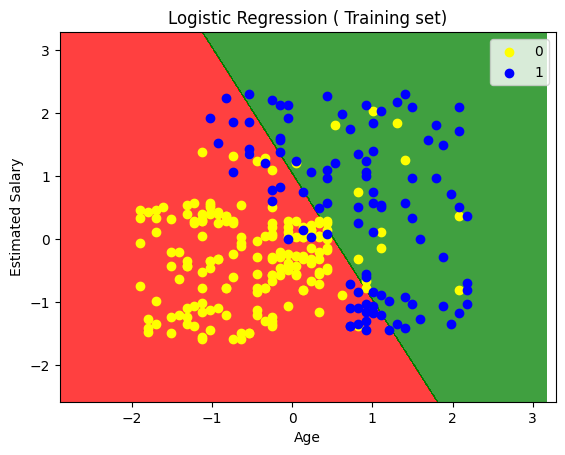

In [412]:
# Visualising the Training set results
 
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:,0].min() -1, stop = X_Set[:, 0].max() +1, step = 0.01),
                     np.arange(start = X_Set[:,1].min() -1, stop = X_Set[:, 1].max() +1, step = 0.01))
 
 
plt.contourf(X1,X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
 
plt.xlim(X1.min(), X2.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],
                c = ListedColormap(('yellow', 'blue'))(i), label = j)
plt.title('Logistic Regression ( Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()